Gradient descent sounds abstract until you can see the two things it repeats: **measure how wrong the model is**, then **nudge its parameters in the direction that makes it less wrong**.

We will fit a line, $\hat{y} = wx + b$, to noisy observations. No machine-learning library will do the optimization for us. By the end, you will be able to explain every line of the training loop.

## The objective

For $n$ observations, mean squared error is

$$
J(w,b) = \frac{1}{n} \sum_{i=1}^{n} (wx_i + b - y_i)^2.
$$

Its gradients tell us how a small change in each parameter changes the loss:

$$
\frac{\partial J}{\partial w}=\frac{2}{n}\sum_i x_i(\hat y_i-y_i),
\qquad
\frac{\partial J}{\partial b}=\frac{2}{n}\sum_i(\hat y_i-y_i).
$$

We move *against* those gradients using learning rate $\eta$: $w \leftarrow w-\eta\nabla_w J$ and $b \leftarrow b-\eta\nabla_b J$.

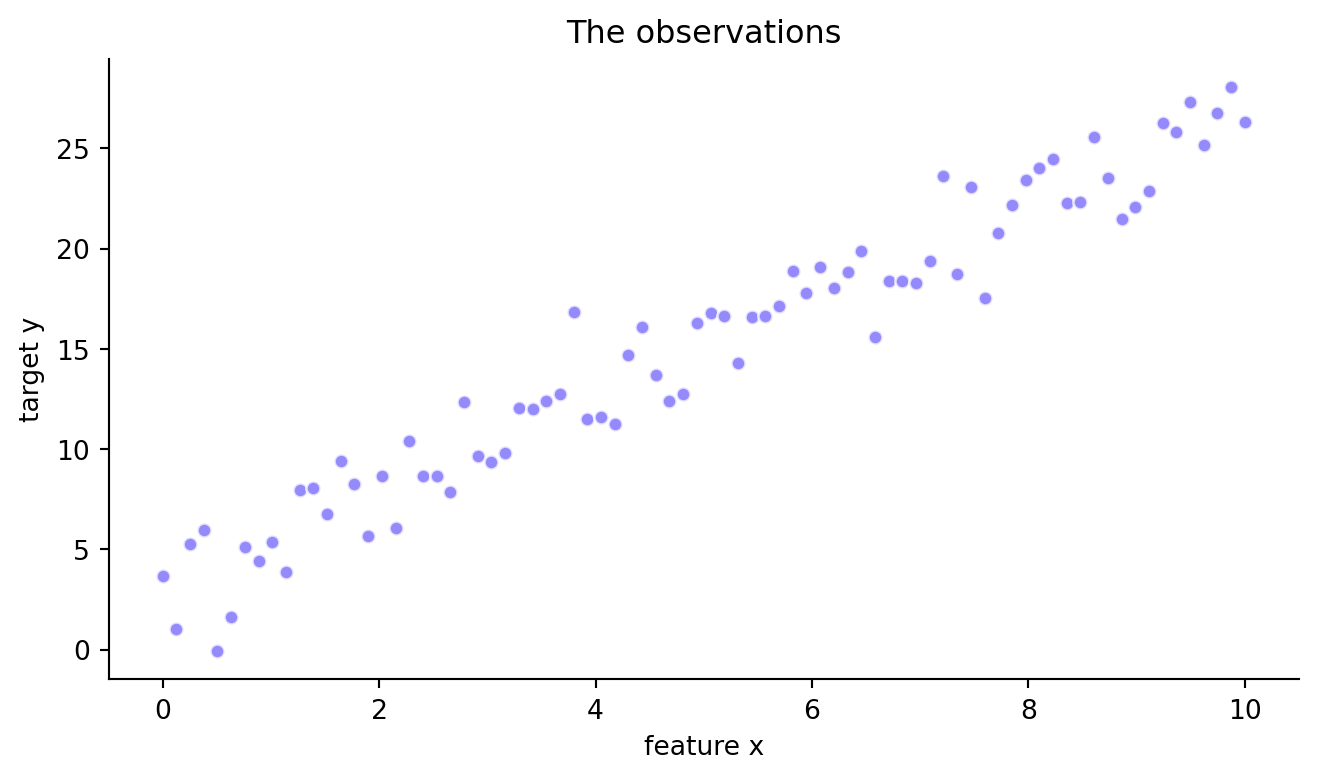

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
x = np.linspace(0, 10, 80)
y = 2.4 * x + 3.0 + rng.normal(0, 2.2, size=x.size)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.scatter(x, y, s=28, alpha=.72, color="#6d5dfc", edgecolor="white")
ax.set(title="The observations", xlabel="feature x", ylabel="target y")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## The entire training loop

The loop below saves occasional checkpoints so we can inspect the journey without printing all 600 updates. Notice that prediction, error, gradient, and update each get one small block.

In [2]:
def fit_line_with_gradient_descent(x, y, learning_rate=0.01, steps=600):
    w, b = 0.0, 0.0
    history = []

    for step in range(steps + 1):
        prediction = w * x + b
        error = prediction - y
        loss = np.mean(error ** 2)

        if step < 5 or step % 50 == 0:
            history.append({"step": step, "w": w, "b": b, "mse": loss})

        grad_w = 2 * np.mean(x * error)
        grad_b = 2 * np.mean(error)
        w -= learning_rate * grad_w
        b -= learning_rate * grad_b

    return w, b, pd.DataFrame(history)

w, b, history = fit_line_with_gradient_descent(x, y)
history.tail().round(3)

,step,w,b,mse
12,400,2.445,2.739,2.899
13,450,2.433,2.819,2.886
14,500,2.424,2.882,2.878
15,550,2.417,2.931,2.873
16,600,2.411,2.969,2.870


The loss should fall quickly at first, then improve in smaller increments. That is expected: far from the minimum, the slope is steep; near the minimum, the same gradient signal becomes small.

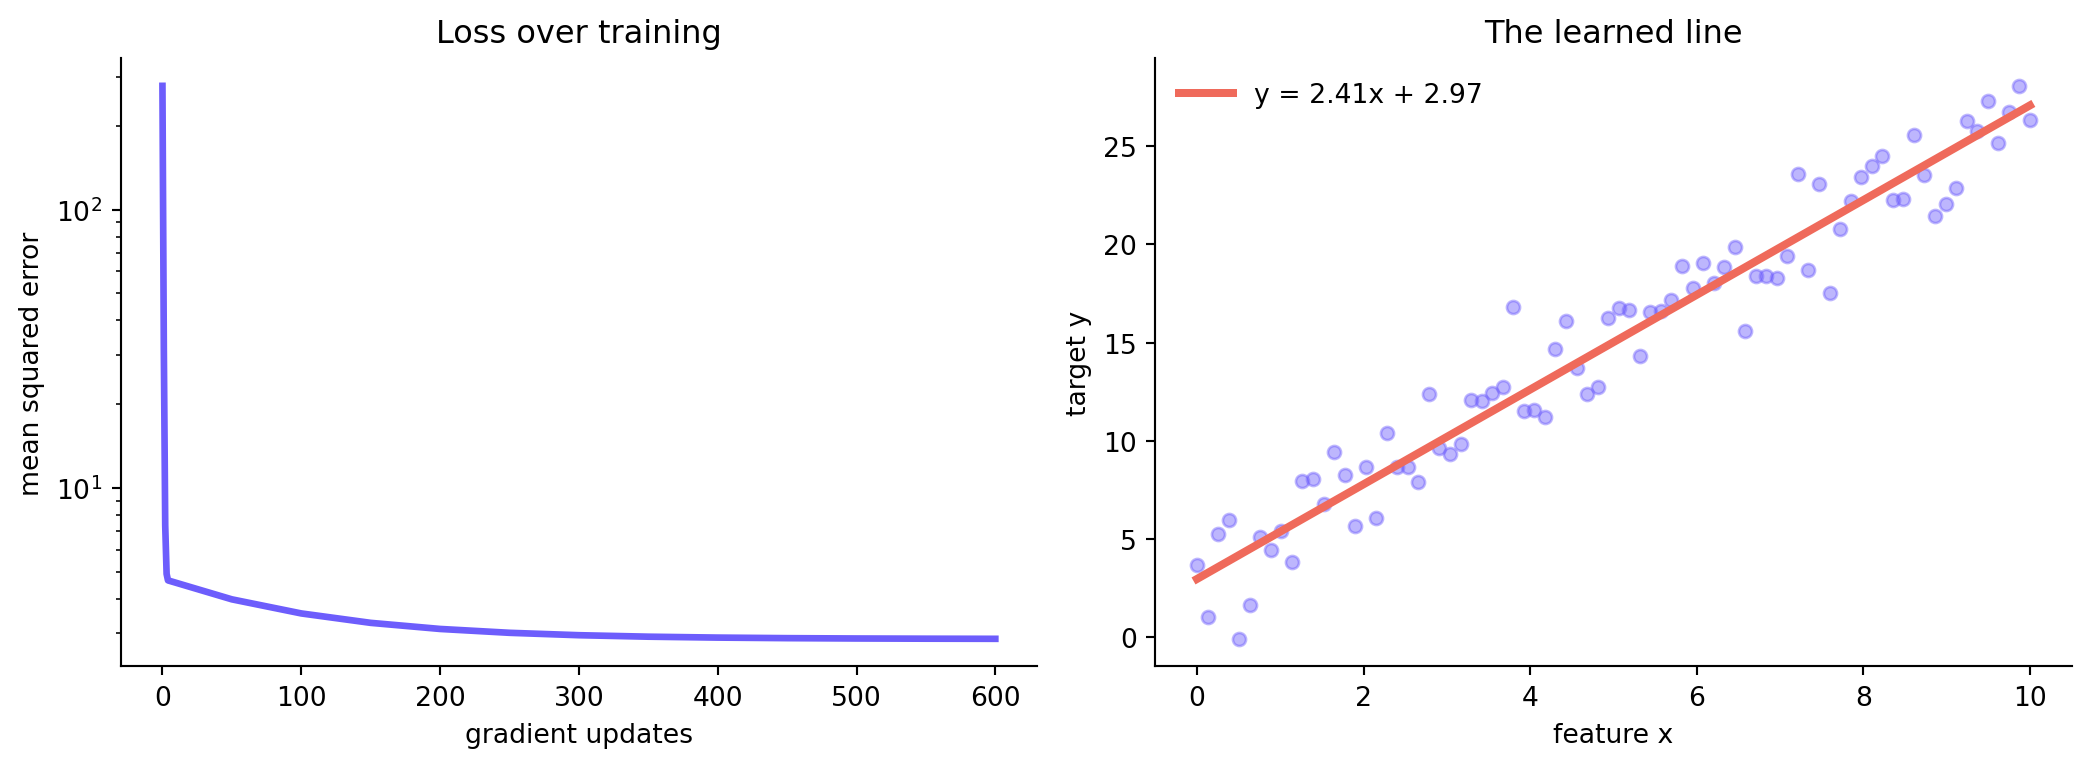

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.1))

axes[0].plot(history["step"], history["mse"], color="#6d5dfc", linewidth=2.5)
axes[0].set(title="Loss over training", xlabel="gradient updates", ylabel="mean squared error")
axes[0].set_yscale("log")

axes[1].scatter(x, y, s=24, alpha=.45, color="#6d5dfc")
axes[1].plot(x, w * x + b, color="#ef6a5b", linewidth=3, label=f"y = {w:.2f}x + {b:.2f}")
axes[1].set(title="The learned line", xlabel="feature x", ylabel="target y")
axes[1].legend(frameon=False)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## The learning rate is a step-size decision

A small rate is safe but slow. A useful rate reaches the basin quickly. A large rate can jump across the basin and diverge. Let us compare the first 80 updates.

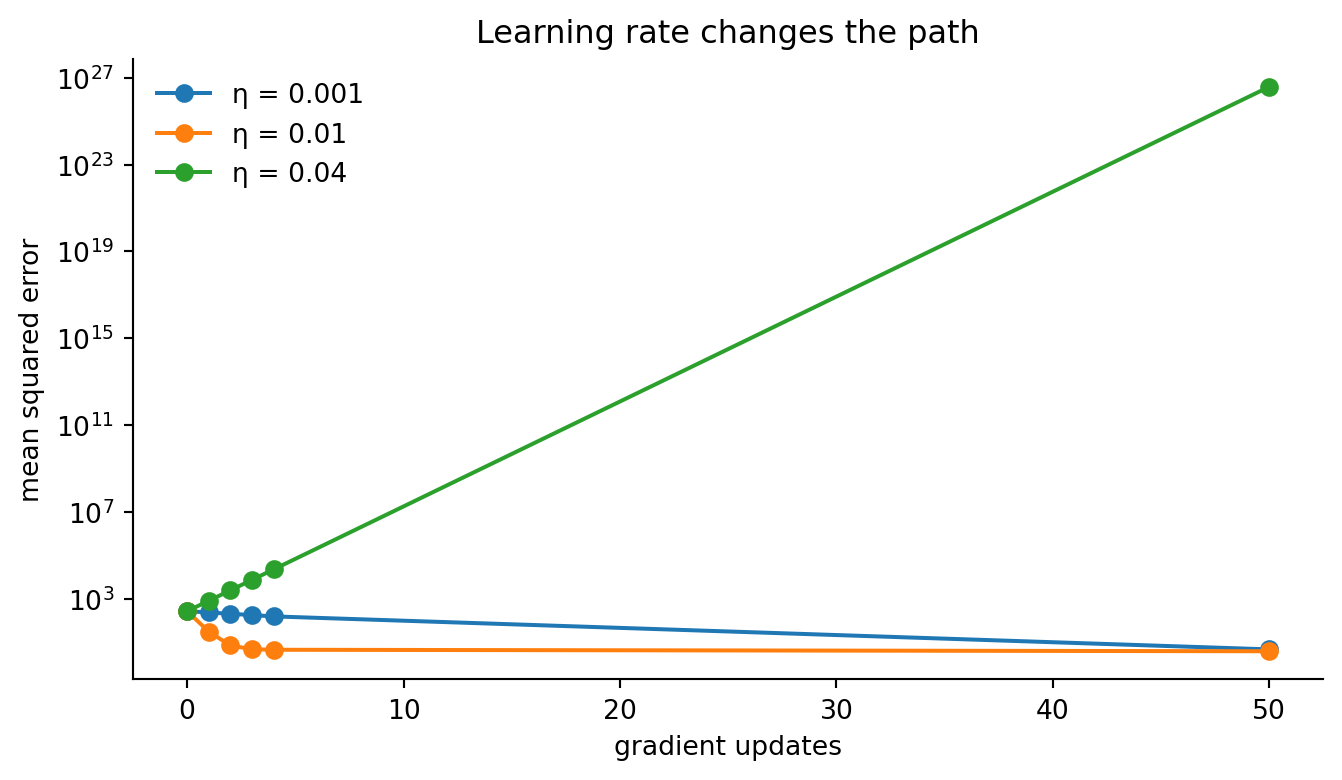

In [4]:
rates = [0.001, 0.01, 0.04]
fig, ax = plt.subplots(figsize=(8, 4.2))

for rate in rates:
    _, _, rate_history = fit_line_with_gradient_descent(x, y, learning_rate=rate, steps=80)
    ax.plot(rate_history["step"], rate_history["mse"], marker="o", label=f"η = {rate}")

ax.set(title="Learning rate changes the path", xlabel="gradient updates", ylabel="mean squared error")
ax.set_yscale("log")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## What to remember

- A loss function turns model quality into a number we can optimize.
- A gradient gives a local direction; it does not promise the whole route.
- The learning rate controls how aggressively we trust that local direction.
- Plotting the loss is a basic diagnostic. `nan`, oscillation, or a rising curve usually points to an unstable rate, unscaled features, or a bug.

**Try next:** rescale `x` by 100 while keeping the learning rate fixed. Then standardize `x` and compare the two loss curves. You will see why feature scaling changes optimization even when it does not change the best possible fitted line.